# Monte Carlo ETF Portfolio Simulation

In another project I have been working on, I was taking in financial client preferences and building portfolios that fit each person's needs. While working on that project and taking this class, it got me thinking, if we are building these portfolios, then what? I wanted to explore how we could quantify the future of each portfolio and better understand the range of outcomes that investors might experience over time.

The questions I decided to answer through this project is 
1. What level of return can we expect, on average, from an ETF portfolio over a given investment horizon?
2. How much variability exists around that expected value?
3. What is the probability that the portfolio breaches a threshold before the given time horizon?
4. If the portfolio breaches that threshold, when is it most likely to occur? (distribution of exit times)
5. What is the survival probability through time?

Stochastic Process - We know that volatility is not constant in finance, and that's part of what makes predicting markets so hard. The past won't tell us exactly how a stock will return in the future, but by assuming a constant mean return and covariance matrix, I can use historical ETF data to generate thousands of possible future paths the portfolio may take. While this assumption is not perfect, it is commonly used in Monte Carlo simulations and provides useful information for making investment decisions.

1. Daily ETF returns are modeled as a discrete time vector valued stochastic process: Rt ~ N(mu, Sigma)
   - Rt = simulated vector of ETF returns at time t, mu = expected return vector using historical ETF returns, Sigma = covariance matrix of the ETFs
2. Portfolio returns are generated using portfolio weights: Rp,t = wᵀRt
   - Rp,t = portfolio return at time t, wᵀ = portfolio weight vector (transpose)
3. Portfolio values are updated through compounding: Vt = Vt-1(1 + Rp,t)
   - Vt = portfolio value at time t = portfolio return at time t, Vt-1 = portfolio value at the previous time step(t-1)
4. The first exit time: tau = min{t : Portfolio Loss ≥ L or Portfolio Drawdown ≥ D}
   - tau = first exit time, L = maximum acceptable loss, D = maximum acceptable drawdown(how far a portfolio falls from its highest value reached so far) - these will change based on the users risk level(conservative, balanced or growth portfolio)

This process is repeated for each day in the investment time line and thousands of simulations to generate a distribution of possible portfolio outcomes.

In [1]:
# Import libraries needed 
from __future__ import annotations

from dataclasses import dataclass
from datetime import date

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import yfinance as yf

# Set plotting and display options
plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.max_rows", 100)
pd.set_option("display.float_format", "{:.4f}".format)

Set constants for the project- trading days, ETF universe and the risk profiles need to be set up.  Looked into max loss and drawdown for profiles that can be categorized as Conservative, Balanced, or Growth then set those, so the profiles can follow those rules when running the simulation

In [2]:
TRADING_DAYS = 252
ETF_UNIVERSE = ['AGG', 'AQWA', 'BIL', 'BIV', 'BND', 'BNDX', 'CHRI', 'EDV', 'ERTH', 'HYG', 'HYMB', 'ICF', 'ICLN', 'IEF', 'IJH', 'IJR', 'ITOT', 'IVV', 'IWF', 'IWR', 'JPST', 'LQD', 'MBB', 'MUB', 'OCEN', 'PFF', 'QQQ', 'SCHD', 'SCHH', 'SDG', 'SPDW', 'SPY', 'SPYD', 'SRI', 'TAN', 'TLT', 'USHY', 'VDC', 'VEA', 'VEU', 'VGT', 'VIG', 'VNQ', 'VNQI', 'VTEB', 'VTI', 'VTV', 'VUG', 'VWO', 'VXUS', 'VYM', 'XLK']

RISK_PROFILE_RULES = {
    "Conservative": {"max_loss": 0.10, "max_drawdown": 0.15},
    "Balanced": {"max_loss": 0.18, "max_drawdown": 0.25},
    "Growth": {"max_loss": 0.30, "max_drawdown": 0.40},
}

Load ETF universe data from the ETF universe I was provided by my client in the other project, define functions to load data, make sure ETf us is the ETF universe and download the ETF data from Yahoofinance and compute returns + annualize

In [3]:
def load_etf_universe() -> list[str]:
    return ETF_UNIVERSE.copy()


In [4]:
universe = load_etf_universe()
pd.DataFrame({"Allowed ETF Universe": universe})

,Allowed ETF Universe
0,AGG
1,AQWA
2,BIL
3,BIV
4,BND
5,BNDX
6,CHRI
7,EDV
8,ERTH
9,HYG


Make portfolio and simulation inputs - weights are decimals that sum to 1.0
- doing this with a random portfolio of 3 ETFs all the same weight to try and build it

Store and validate a portfolio made up of ETF tickers and weights. This checks that: tickers and weights match, no duplicate ETFs exist, weights are valid numbers, weights are normalized to sum to 1. It then stores the portfolio if it works

In [5]:
@dataclass(frozen=True)
class Portfolio:
    tickers: tuple[str, ...]
    weights: np.ndarray
    name: str = "Custom Portfolio"

    def __post_init__(self) -> None:
        clean_tickers = tuple(ticker.strip().upper() for ticker in self.tickers)
        weights = np.asarray(self.weights, dtype=float)

        if len(clean_tickers) == 0:
            raise ValueError("Portfolio must contain at least one ETF.")
        if len(clean_tickers) != len(weights):
            raise ValueError("Tickers and weights must have the same length.")
        if len(set(clean_tickers)) != len(clean_tickers):
            raise ValueError("Duplicate tickers are not allowed.")
        if np.any(weights < 0):
            raise ValueError("Weights must be nonnegative.")
        if not np.isfinite(weights).all():
            raise ValueError("Weights must be finite numbers.")
        if weights.sum() <= 0:
            raise ValueError("At least one weight must be positive.")

        normalized = weights / weights.sum()
        object.__setattr__(self, "tickers", clean_tickers)
        object.__setattr__(self, "weights", normalized)

    def to_frame(self) -> pd.DataFrame:
        return pd.DataFrame({"ticker": self.tickers, "weight": self.weights})

In [6]:
def validate_against_universe(portfolio: Portfolio, universe: list[str]) -> None:
    allowed = set(universe)

In [7]:
TICKERS = ("BND", "VTI", "VEA")
WEIGHTS = np.array([1/3, 1/3, 1/3])
STARTING_VALUE = 100_000
HORIZON_YEARS = 5
N_SIMULATIONS = 10_000
HISTORICAL_START_DATE = "2015-01-01"
RISK_PROFILE = "Balanced"
RANDOM_SEED = 42

portfolio = Portfolio(TICKERS, WEIGHTS, name="Example ETF Portfolio")
validate_against_universe(portfolio, universe)

portfolio.to_frame()

,ticker,weight
0,BND,0.3333
1,VTI,0.3333
2,VEA,0.3333


Based on the input the risk profile is made from the risk rules defined ubove 

In [8]:
risk_rule = RISK_PROFILE_RULES[RISK_PROFILE]
pd.DataFrame(
    {
        "Risk profile": [RISK_PROFILE],
        "Maximum loss from start": [risk_rule["max_loss"]],
        "Maximum drawdown": [risk_rule["max_drawdown"]],
    }
).style.format({"Maximum loss from start": "{:.0%}", "Maximum drawdown": "{:.0%}"})

,Risk profile,Maximum loss from start,Maximum drawdown
0,Balanced,18%,25%


## Data Collection from Yahoo Finance

The model estimates daily returns from closing prices

In [9]:
def compute_simple_returns(prices: pd.DataFrame) -> pd.DataFrame:
    returns = prices.pct_change().dropna()
    return returns

def download_adjusted_prices(tickers: list[str] | tuple[str, ...], start: str | date = "2015-01-01", end: str | date | None = None) -> pd.DataFrame:
    data = yf.download(list(tickers), start=start, end=end, auto_adjust=True, progress=False, group_by="column", threads=True)
    if isinstance(data.columns, pd.MultiIndex):
        prices = data["Close"]
    else:
        prices = data.rename("Close").to_frame()
        prices.columns = list(tickers)
    prices = prices.dropna(axis=1, how="all").ffill().dropna()
    return prices.loc[:, list(tickers)]

In [10]:
prices = download_adjusted_prices(portfolio.tickers, start=HISTORICAL_START_DATE)
returns = compute_simple_returns(prices)

display(prices.tail())
display(returns.describe().T)

Ticker,BND,VTI,VEA
Date,,,
2026-06-02,73.2000,374.3600,72.3200
2026-06-03,73.0600,371.6500,71.6700
2026-06-04,73.1600,373.3800,71.8400
2026-06-05,72.8300,363.3800,69.1700
2026-06-08,72.8100,364.4700,69.8600


,count,mean,std,min,25%,50%,75%,max
Ticker,,,,,,,,
BND,2873.0000,0.0001,0.0033,-0.0544,-0.0015,0.0001,0.0018,0.0422
VTI,2873.0000,0.0006,0.0113,-0.1138,-0.0039,0.0007,0.0061,0.1015
VEA,2873.0000,0.0004,0.0109,-0.1118,-0.0048,0.0008,0.0061,0.0890


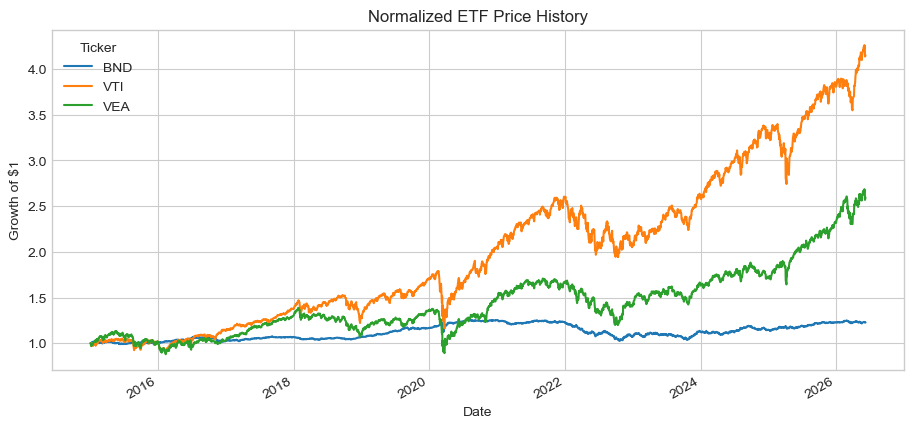

In [11]:
fig, ax = plt.subplots(figsize=(11, 5))
(prices / prices.iloc[0]).plot(ax=ax)
ax.set_title("Normalized ETF Price History")
ax.set_ylabel("Growth of $1")
ax.set_xlabel("Date")
plt.show()

# Estimate Parameteres
Fit a multivariate normal model using historical ETF returns which estimates the mean return vector and covariance matrix from historical ETF returns, then uses them to simulate future ETF returns.

In [12]:
def annualize_daily_simple_return(daily_return: np.ndarray | float, trading_days: int = TRADING_DAYS) -> np.ndarray | float:
    return (1.0 + daily_return) ** trading_days - 1.0

@dataclass(frozen=True)
class MultivariateNormalModel:
    mean: np.ndarray
    covariance: np.ndarray
    asset_names: tuple[str, ...]
    name: str = "Multivariate normal returns"

    @classmethod
    def fit(cls, returns: pd.DataFrame) -> "MultivariateNormalModel":
        return cls(mean=returns.mean().to_numpy(), covariance=returns.cov().to_numpy(), asset_names=tuple(returns.columns))

    def annualized_mean(self) -> np.ndarray:
        return annualize_daily_simple_return(self.mean)

    def simulate_asset_returns(self, n_steps: int, n_simulations: int, random_seed: int | None = None) -> np.ndarray:
        rng = np.random.default_rng(random_seed)
        draws = rng.multivariate_normal(self.mean, self.covariance, size=(n_simulations, n_steps))
        return np.clip(draws, -0.95, None)


In [13]:
model = MultivariateNormalModel.fit(returns)

parameter_table = pd.DataFrame(
    {
        "ticker": model.asset_names,
        "daily_drift": model.mean,
        "annualized_drift": model.annualized_mean(),
        "daily_volatility": returns.std().to_numpy(),
        "annualized_volatility": returns.std().to_numpy() * np.sqrt(TRADING_DAYS),
    }
)

parameter_table.style.format(
    {
        "daily_drift": "{:.4%}",
        "annualized_drift": "{:.2%}",
        "daily_volatility": "{:.4%}",
        "annualized_volatility": "{:.2%}",
    }
)

,ticker,daily_drift,annualized_drift,daily_volatility,annualized_volatility
0,BND,0.0076%,1.95%,0.3350%,5.32%
1,VTI,0.0560%,15.15%,1.1327%,17.98%
2,VEA,0.0392%,10.38%,1.0939%,17.36%


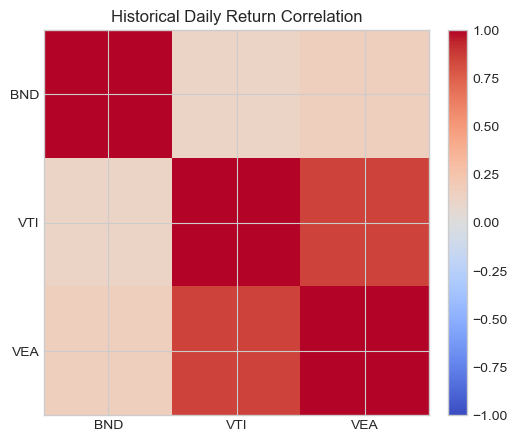

Ticker,BND,VTI,VEA
Ticker,,,
BND,1.0000,0.1217,0.1634
VTI,0.1217,1.0000,0.8592
VEA,0.1634,0.8592,1.0000


In [14]:
correlation = returns.corr()
fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(correlation, vmin=-1, vmax=1, cmap="coolwarm")
ax.set_xticks(range(len(correlation.columns)))
ax.set_yticks(range(len(correlation.index)))
ax.set_xticklabels(correlation.columns)
ax.set_yticklabels(correlation.index)
ax.set_title("Historical Daily Return Correlation")
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.show()

correlation

## Monte Carlo Simulation

The simulation generates correlated daily ETF returns, computes portfolio returns, and compounds those returns into portfolio value paths.

In [15]:
# Convert the investment horizon from years into trading days
def horizon_to_steps(years: float, trading_days: int = TRADING_DAYS) -> int:
    if years <= 0:
        raise ValueError("Investment horizon must be positive.")

    return max(1, int(round(years * trading_days)))

In [16]:
# Make sure the portfolio weights and return model line up correctly
def validate_portfolio_model_alignment(portfolio: Portfolio, model: MultivariateNormalModel) -> None:
    if not np.isclose(portfolio.weights.sum(), 1.0):
        raise ValueError("Portfolio weights must sum to 1.0.")
    if np.any(portfolio.weights < 0) or np.any(portfolio.weights > 1):
        raise ValueError("Portfolio weights must be decimal allocations between 0 and 1.")
    if tuple(model.asset_names) != portfolio.tickers:
        raise ValueError("Portfolio tickers must be in the same order as model.asset_names. " f"Portfolio order: {portfolio.tickers}; model order: {tuple(model.asset_names)}")


In [17]:

def run_monte_carlo(portfolio: Portfolio, model: MultivariateNormalModel, starting_value: float = 100_000, years: float = 5, n_simulations: int = 10_000, random_seed: int | None = None) -> SimulationResult:
    if starting_value <= 0:
        raise ValueError("Starting value must be positive.")
    if n_simulations <= 0:
        raise ValueError("Number of simulations must be positive.")
    validate_portfolio_model_alignment(portfolio, model)
    n_steps = horizon_to_steps(years)
    asset_returns = model.simulate_asset_returns(n_steps, n_simulations, random_seed)
    if asset_returns.shape[2] != len(portfolio.weights):
        raise ValueError("Simulated asset return dimension must match number of portfolio weights.")
    portfolio_returns = asset_returns @ portfolio.weights
    growth = np.cumprod(1.0 + portfolio_returns, axis=1)
    path_values = np.column_stack([np.full(n_simulations, starting_value), starting_value * growth])
    index = pd.RangeIndex(0, n_steps + 1, name="day")
    columns = pd.RangeIndex(1, n_simulations + 1, name="simulation")
    return_index = pd.RangeIndex(1, n_steps + 1, name="day")
    return SimulationResult(portfolio=portfolio, paths=pd.DataFrame(path_values.T, index=index, columns=columns), portfolio_returns=pd.DataFrame(portfolio_returns.T, index=return_index, columns=columns), model_name=model.name)


In [18]:
@dataclass(frozen=True)
class SimulationResult:
    portfolio: Portfolio
    paths: pd.DataFrame
    portfolio_returns: pd.DataFrame
    model_name: str
    time_step_days: int = 1

    @property
    def ending_values(self) -> pd.Series:
        return self.paths.iloc[-1]

In [19]:
result = run_monte_carlo(
    portfolio=portfolio,
    model=model,
    starting_value=STARTING_VALUE,
    years=HORIZON_YEARS,
    n_simulations=N_SIMULATIONS,
    random_seed=RANDOM_SEED,
)

result.paths.shape, result.portfolio_returns.shape

((1261, 10000), (1260, 10000))

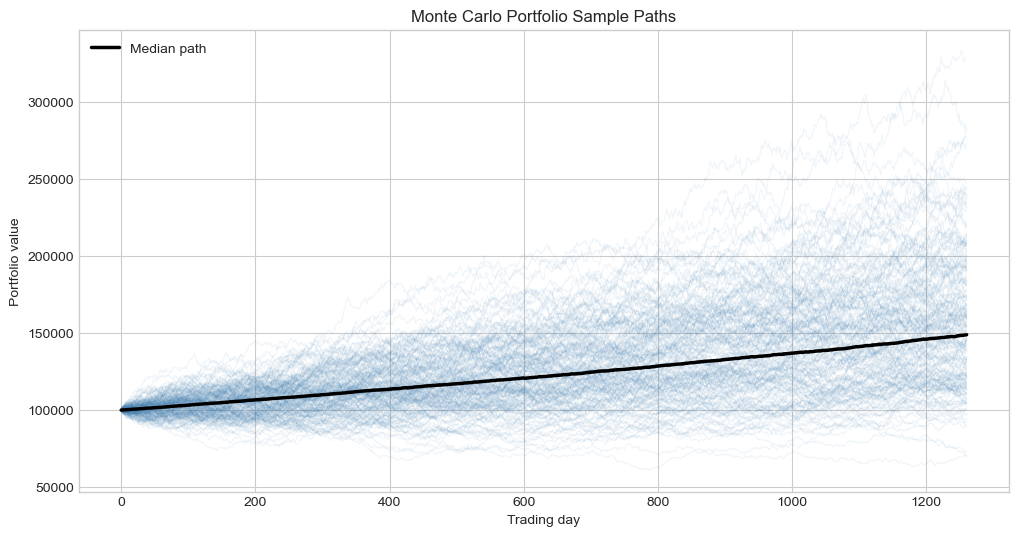

In [20]:
fig, ax = plt.subplots(figsize=(12, 6))
sample_paths = result.paths.iloc[:, :200]
ax.plot(sample_paths.index, sample_paths, color="steelblue", alpha=0.08, linewidth=0.8)
ax.plot(result.paths.index, result.paths.median(axis=1), color="black", linewidth=2.5, label="Median path")
ax.set_title("Monte Carlo Portfolio Sample Paths")
ax.set_xlabel("Trading day")
ax.set_ylabel("Portfolio value")
ax.legend()
plt.show()

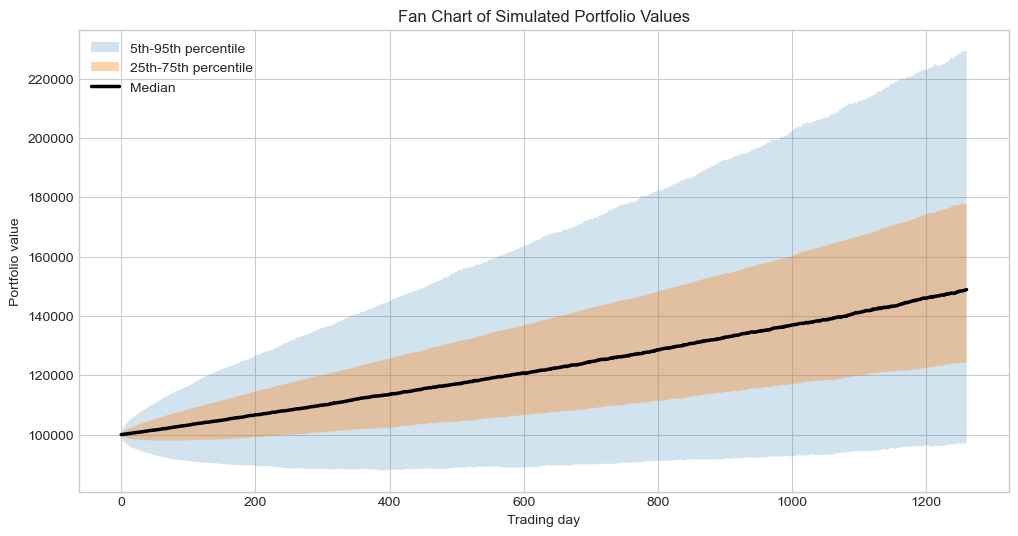

In [21]:
percentiles = result.paths.quantile([0.05, 0.25, 0.50, 0.75, 0.95], axis=1).T

fig, ax = plt.subplots(figsize=(12, 6))
ax.fill_between(percentiles.index, percentiles[0.05], percentiles[0.95], alpha=0.20, label="5th-95th percentile")
ax.fill_between(percentiles.index, percentiles[0.25], percentiles[0.75], alpha=0.35, label="25th-75th percentile")
ax.plot(percentiles.index, percentiles[0.50], color="black", linewidth=2.5, label="Median")
ax.set_title("Fan Chart of Simulated Portfolio Values")
ax.set_xlabel("Trading day")
ax.set_ylabel("Portfolio value")
ax.legend()
plt.show()

# Return and Risk Metrics
Calculate the maximum drawdown for each simulated portfolio path, calculate summary statistics from the Monte Carlo simulation
- Annual Return (CAGR): Expected portfolio growth rate each year
- Volatility: Variability of returns
- Downside Deviation:  Variability of negative returns only
- Maximum Drawdown: Largest decline from a previous portfolio max
- VaR : Loss threshold expected to be exceeded only 5% of the time
- CVaR : Average loss in the worst 5% of outcomes
- Sharpe Ratio : Risk adjusted return

In [22]:
def maximum_drawdown(paths: pd.DataFrame) -> pd.Series:
    drawdowns = paths / paths.cummax() - 1.0
    return drawdowns.min(axis=0)


def summarize_simulation(result: SimulationResult, starting_value: float, risk_free_rate: float = 0.0, var_level: float = 0.05) -> dict[str, float]:
    ending_values = result.ending_values
    total_returns = ending_values / starting_value - 1.0
    n_years = (len(result.paths.index) - 1) / TRADING_DAYS
    annual_returns = (1.0 + total_returns).pow(1.0 / n_years) - 1.0
    daily_portfolio_returns = result.portfolio_returns
    annual_volatility = daily_portfolio_returns.std(axis=0) * np.sqrt(TRADING_DAYS)
    downside = daily_portfolio_returns.clip(upper=0).std(axis=0) * np.sqrt(TRADING_DAYS)
    mdd = maximum_drawdown(result.paths)
    var = total_returns.quantile(var_level)
    cvar = total_returns[total_returns <= var].mean()
    sharpe = (annual_returns.mean() - risk_free_rate) / annual_volatility.mean()
    return {"mean_ending_value": float(ending_values.mean()), "median_ending_value": float(ending_values.median()), "expected_annual_return": float(annual_returns.mean()), "median_annual_return": float(annual_returns.median()), "annual_volatility": float(annual_volatility.mean()), "downside_deviation": float(downside.mean()), "mean_max_drawdown": float(mdd.mean()), "probability_of_loss": float((ending_values < starting_value).mean()), "value_at_risk": float(var), "conditional_value_at_risk": float(cvar), "sharpe_ratio": float(sharpe)}

def format_summary_table(metrics: dict[str, float]) -> pd.DataFrame:
    labels = {"mean_ending_value": "Mean terminal value", "median_ending_value": "Median terminal value", "expected_annual_return": "Mean CAGR", "median_annual_return": "Median CAGR", "annual_volatility": "Annual volatility", "downside_deviation": "Downside deviation", "mean_max_drawdown": "Mean maximum drawdown", "probability_of_loss": "Probability of loss", "value_at_risk": "5% VaR", "conditional_value_at_risk": "5% CVaR", "sharpe_ratio": "Sharpe ratio", "exit_probability": "Threshold breach probability", "survival_probability": "Survival probability", "expected_exit_day": "Average exit time", "median_exit_day": "Median exit time"}
    hidden_keys = {"expected_exit_time_years", "median_exit_time_years"}
    formatted_values = {"expected_exit_day": format_trading_day_years(metrics.get("expected_exit_day")), "median_exit_day": format_trading_day_years(metrics.get("median_exit_day"))}
    return pd.DataFrame([{"metric": labels.get(key, key), "value": formatted_values.get(key, value)} for key, value in metrics.items() if key not in hidden_keys])



In [23]:
@dataclass(frozen=True)
class ExitTimeResult:
    exit_occurred: pd.Series
    first_exit_day: pd.Series
    rule: dict[str, float]

    def summary(self) -> dict[str, float]:
        exit_days = self.first_exit_day.dropna()
        return {"exit_probability": float(self.exit_occurred.mean()), "survival_probability": float(1.0 - self.exit_occurred.mean()), "expected_exit_day": float(exit_days.mean()) if not exit_days.empty else np.nan, "median_exit_day": float(exit_days.median()) if not exit_days.empty else np.nan, "expected_exit_time_years": float(trading_days_to_years(exit_days.mean())) if not exit_days.empty else np.nan, "median_exit_time_years": float(trading_days_to_years(exit_days.median())) if not exit_days.empty else np.nan}


def calculate_exit_times(paths: pd.DataFrame, risk_profile: str = "Balanced") -> ExitTimeResult:
    if risk_profile not in RISK_PROFILE_RULES:
        raise ValueError(f"Unknown risk profile: {risk_profile}")
    rule = RISK_PROFILE_RULES[risk_profile]
    start = paths.iloc[0]
    running_peak = paths.cummax()
    loss_from_start = paths / start - 1.0
    drawdown = paths / running_peak - 1.0
    breach = (loss_from_start <= -rule["max_loss"]) | (drawdown <= -rule["max_drawdown"])
    exit_occurred = breach.any(axis=0)
    first_exit_day = breach.idxmax(axis=0).where(exit_occurred, other=np.nan)
    return ExitTimeResult(exit_occurred=exit_occurred, first_exit_day=first_exit_day, rule=rule)


In [25]:
#helper function to turn trading days to years for presenting results in the correct formatting 
def trading_days_to_years(days: float, trading_days_per_year: int = TRADING_DAYS) -> float:
    return days / trading_days_per_year

def format_trading_day_years(days: float, trading_days_per_year: int = TRADING_DAYS) -> str:
    if pd.isna(days):
        return "N/A"
    years = trading_days_to_years(days, trading_days_per_year)
    return f"{days:,.0f} days ({years:.1f} years)"


In [26]:
exit_result = calculate_exit_times(result.paths, risk_profile=RISK_PROFILE)
metrics = summarize_simulation(result, starting_value=STARTING_VALUE)
metrics.update(exit_result.summary())

summary_table = format_summary_table(metrics)
summary_table

,metric,value
0,Mean terminal value,154173.1501
1,Median terminal value,148863.1094
2,Mean CAGR,0.0844
3,Median CAGR,0.0828
4,Annual volatility,0.1175
5,Downside deviation,0.0667
6,Mean maximum drawdown,-0.1829
7,Probability of loss,0.0624
8,5% VaR,-0.0300
9,5% CVaR,-0.1344


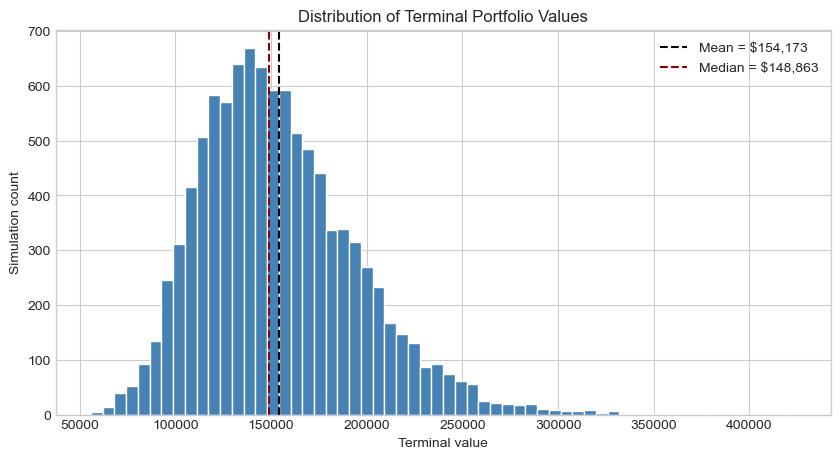

In [27]:
ending_values = result.ending_values

fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(ending_values, bins=60, color="steelblue", edgecolor="white")
ax.axvline(ending_values.mean(), color="black", linestyle="--", label=f"Mean = ${ending_values.mean():,.0f}")
ax.axvline(ending_values.median(), color="darkred", linestyle="--", label=f"Median = ${ending_values.median():,.0f}")
ax.set_title("Distribution of Terminal Portfolio Values")
ax.set_xlabel("Terminal value")
ax.set_ylabel("Simulation count")
ax.legend()
plt.show()

## Exit-Time Analysis

For the selected risk profile, a path exits when it breaches either the maximum-loss threshold or the maximum-drawdown threshold. This is the first-passage-time component of the project.

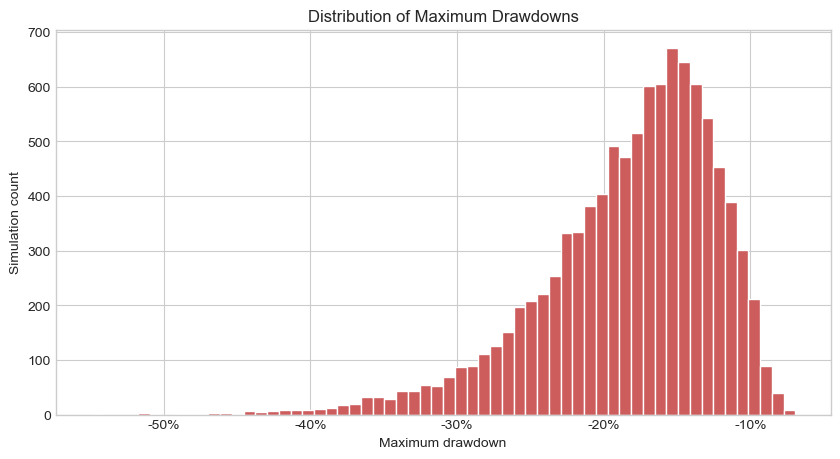

In [28]:
max_drawdowns = maximum_drawdown(result.paths)

fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(max_drawdowns, bins=60, color="indianred", edgecolor="white")
ax.set_title("Distribution of Maximum Drawdowns")
ax.set_xlabel("Maximum drawdown")
ax.set_ylabel("Simulation count")
ax.xaxis.set_major_formatter(lambda x, pos: f"{x:.0%}")
plt.show()

In [29]:
exit_days = exit_result.first_exit_day.dropna()
exit_years = exit_days.apply(trading_days_to_years)

print(f"Threshold breach probability: {metrics['exit_probability']:.1%}")
print(f"Survival probability: {metrics['survival_probability']:.1%}")
print(f"Average exit time: {format_trading_day_years(metrics['expected_exit_day'])}")
print(f"Median exit time: {format_trading_day_years(metrics['median_exit_day'])}")

Threshold breach probability: 16.3%
Survival probability: 83.7%
Average exit time: 629 days (2.5 years)
Median exit time: 588 days (2.3 years)


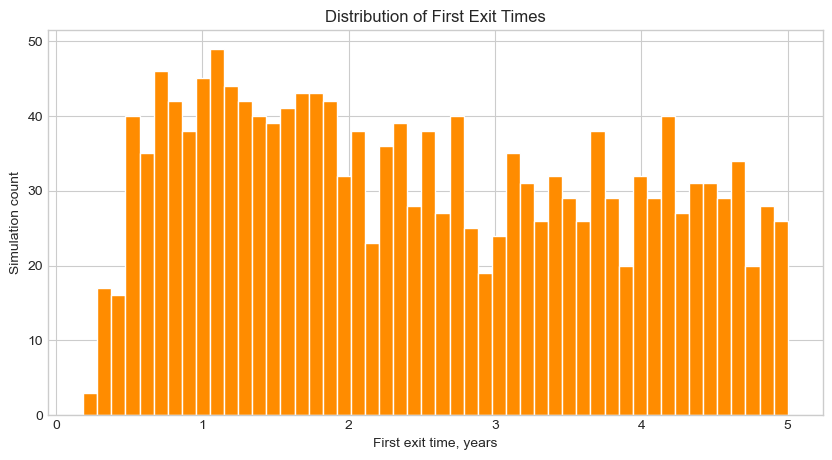

In [30]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(exit_years, bins=50, color="darkorange", edgecolor="white")
ax.set_title("Distribution of First Exit Times")
ax.set_xlabel("First exit time, years")
ax.set_ylabel("Simulation count")
plt.show()

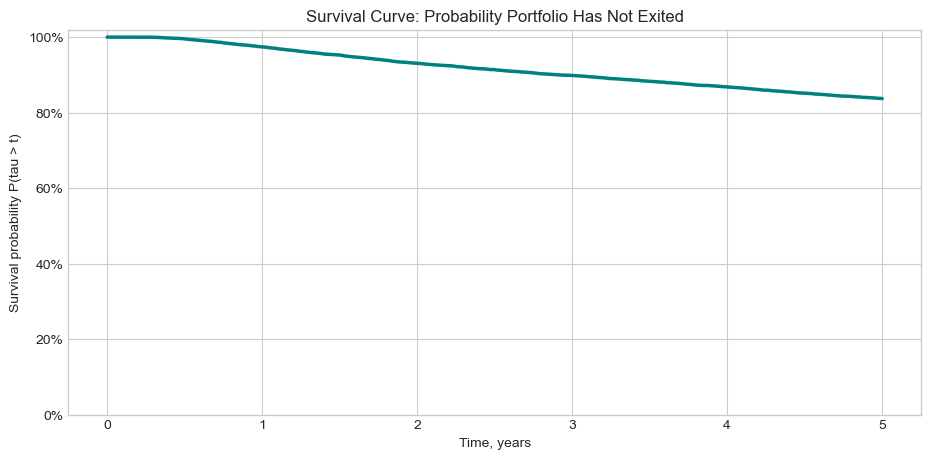

In [31]:
days = np.arange(0, result.paths.index.max() + 1)
survival_probability = np.array([(exit_result.first_exit_day.isna() | (exit_result.first_exit_day > day)).mean() for day in days])
years = days / TRADING_DAYS

fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(years, survival_probability, color="teal", linewidth=2.5)
ax.set_title("Survival Curve: Probability Portfolio Has Not Exited")
ax.set_xlabel("Time, years")
ax.set_ylabel("Survival probability P(tau > t)")
ax.set_ylim(0, 1.02)
ax.yaxis.set_major_formatter(lambda y, pos: f"{y:.0%}")
plt.show()